In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision.datasets import ImageFolder

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [58]:
base_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = ImageFolder('archive/train', transform=base_transform)
val_dataset = ImageFolder('archive/valid', transform=base_transform)
test_dataset = ImageFolder('archive/test', transform=base_transform)

print("Classes:", train_dataset.classes)

Classes: ['0', '1']


In [59]:
#use weighted sampler 
labels = [label for _, label in train_dataset.samples]

class_counts = np.bincount(labels)
weights = 1. / class_counts
sample_weights = [weights[label] for label in labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

In [60]:
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [61]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BaselineCNN(num_classes=len(train_dataset.classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [63]:
def train_model(model, train_loader, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

In [64]:
def validate(model, val_loader):
    model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    print(f"Validation Accuracy: {correct/total:.4f}")

In [65]:
def test_model(model, test_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

Epoch 1, Loss: 0.8958
Epoch 2, Loss: 0.6665
Epoch 3, Loss: 0.5741
Epoch 4, Loss: 0.4214
Epoch 5, Loss: 0.3006
Validation Accuracy: 0.6326

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.78      0.70       208
           1       0.44      0.27      0.34       128

    accuracy                           0.59       336
   macro avg       0.54      0.53      0.52       336
weighted avg       0.56      0.59      0.56       336



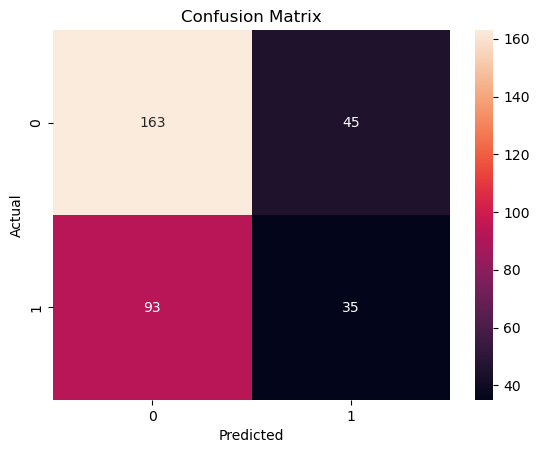

In [66]:
train_model(model, train_loader, epochs=5)
validate(model, val_loader)
test_model(model, test_loader)